# K04 — Something was built here: the SGR and Konza

K02 dated a *natural* change, a lake rising. This notebook asks whether the
same nine years can date *built* change, with no labels, at places where the
answer is already known.

Two railway lines and one new city, all with published dates:

| Place | What happened | When |
|---|---|---|
| **SGR Nairobi–Naivasha** (Phase 2A) | 120 km of new railway down the Rift escarpment | tunnel work from Oct 2016; main construction Jan 2018 – Sep 2019; opened 16 Oct 2019 |
| **SGR Mombasa–Nairobi** | the first SGR line | built 2014–2017; opened 31 May 2017 |
| **Konza Techno City** | a new city on open plain | first office block finished 2019; Phase 1 roads and utilities (170 ha) finished 2022 |

The Mombasa–Nairobi line is the **control**. It opened in the first year of the
record, so it should look built from the start and show little change after.
If the method lights it up just as brightly as the Naivasha line, it is
detecting "railway", not "new railway", and the dates mean nothing.

Where the railway and the city are comes from **OpenStreetMap**
([`data/fetch_osm.py`](../data/fetch_osm.py)), not from TESSERA, so the answer
key is independent.

Sources for the dates: [Kenya SGR (Wikipedia)](https://en.wikipedia.org/wiki/Kenya_Standard_Gauge_Railway),
[AidData: SGR Phase 2A](https://china.aiddata.org/projects/47025/),
[Konza Technopolis (Wikipedia)](https://en.wikipedia.org/wiki/Konza_Technopolis).

**Downloads:** 7 tiles × 9 years = 63 tile-years, about 10 GB on a cold cache.

In [1]:
# ---------------------------------------------------------------------------
# SETUP
# ---------------------------------------------------------------------------
import sys
from pathlib import Path

import numpy as np                    # array maths
import pandas as pd                   # tables
import geopandas as gpd               # the OSM railway and city outline
import matplotlib.pyplot as plt       # every figure below
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from rasterio.features import rasterize

# Jupyter may start in the repo root or in experiments/. Locate src/kenya.py
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src" / "kenya.py").is_file()),
    None,
)
if repo_root is None:
    raise RuntimeError("Could not locate the repository root containing src/kenya.py")
sys.path.insert(0, str(repo_root / "src"))

import kenya as K           # shared helpers for this series — see src/kenya.py

gt = K.client()
YEARS = K.DEEP_YEARS
sgr = gpd.read_file(repo_root / "data" / "osm_sgr.geojson")
konza = gpd.read_file(repo_root / "data" / "osm_konza.geojson")
print(sgr.phase.value_counts().to_string())
print(f"Konza Techno City outline: {konza.to_crs('EPSG:32637').area.sum() / 1e6:.1f} km^2")

phase
other               184
Nairobi-Naivasha     85
Mombasa-Nairobi      48
Konza Techno City outline: 17.4 km^2


## 1. The study area

Seven tiles. Four follow the Naivasha line down the escarpment, where it has
~45 km of track. Three cover Konza: the city plot spans two, and the third
carries 12 km of the Mombasa–Nairobi line, the control.

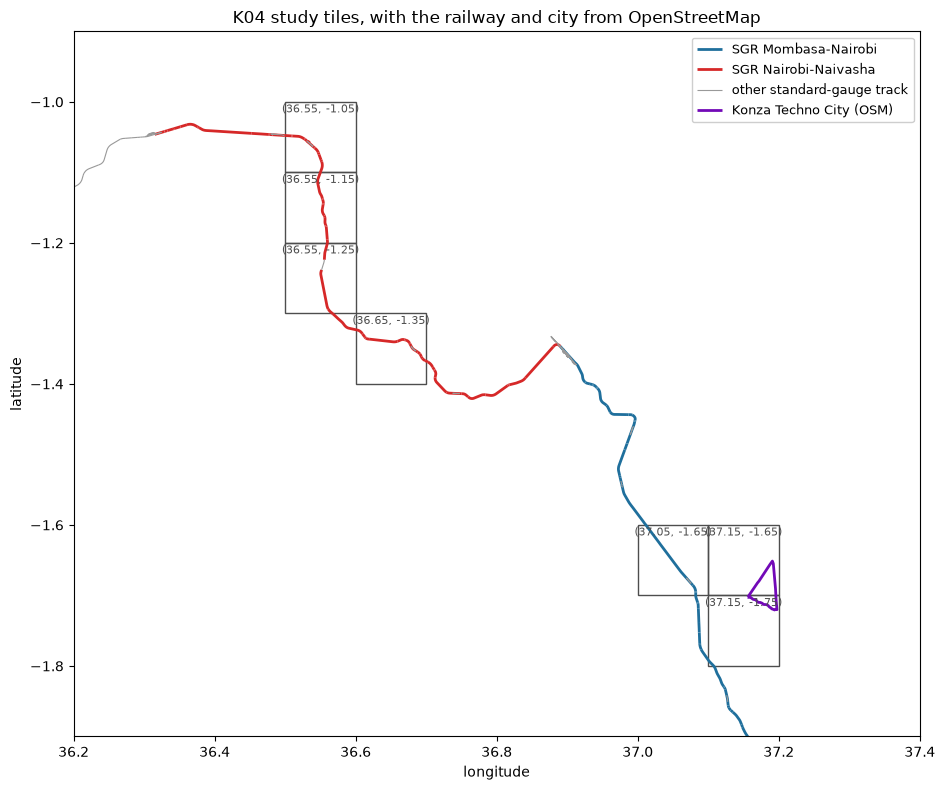

In [2]:
# ---------------------------------------------------------------------------
# THE SEVEN TILES, WITH THE OSM ANSWER KEY
# ---------------------------------------------------------------------------
TILES = {
    (36.55, -1.05): "escarpment", (36.55, -1.15): "escarpment",
    (36.55, -1.25): "escarpment", (36.65, -1.35): "escarpment",
    (37.15, -1.65): "Konza",      (37.15, -1.75): "Konza",
    (37.05, -1.65): "Konza",
}
PHASE_COLOUR = {"Nairobi-Naivasha": "#d62828", "Mombasa-Nairobi": "#1f6f9c", "other": "0.6"}

fig, ax = plt.subplots(figsize=(11, 8))
for (lon, lat), group in TILES.items():
    ax.add_patch(plt.Rectangle((lon - 0.05, lat - 0.05), 0.1, 0.1, fill=False, ec="0.3", lw=1))
    ax.text(lon, lat + 0.035, f"({lon}, {lat})", ha="center", fontsize=8, color="0.3")
for phase, sub in sgr.groupby("phase"):
    sub.plot(ax=ax, color=PHASE_COLOUR[phase], lw=2 if phase != "other" else 0.8,
             label=f"SGR {phase}" if phase != "other" else "other standard-gauge track")
konza.boundary.plot(ax=ax, color="#7209b7", lw=2, label="Konza Techno City (OSM)")
ax.set_xlim(36.2, 37.4); ax.set_ylim(-1.9, -0.9); ax.set_aspect("equal")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.legend(loc="upper right", fontsize=9, framealpha=0.95)
ax.set_title("K04 study tiles, with the railway and city from OpenStreetMap", fontsize=12)
plt.tight_layout(); plt.show()

## 2. Dating every pixel

For each pixel, `K.step_change` looks at its nine fingerprints and finds the
**one split point** where "before" and "after" differ most, weighted so that a
single odd first or last year cannot win. It returns two things per pixel:

- **how much** it changed: the cosine distance between the average before and
  the average after (0 = no change);
- **when**: the first year of the new state.

Every pixel gets a split point, even one that never changed, so the *when* only
means something where the *how much* is large. What counts as large is set in
§3 from background pixels, before looking at the railway.

The results are saved to `outputs/k04_step_change.npz`, so reruns take seconds.

In [3]:
# ---------------------------------------------------------------------------
# STEP CHANGE FOR EVERY PIXEL OF EVERY TILE
# ---------------------------------------------------------------------------
CACHE = repo_root / "outputs" / "k04_step_change.npz"

def tile_geo(lon, lat):
    """(crs, transform, shape) of a tile, from one cached year."""
    emb, crs, transform = K.fetch(gt, lon, lat, YEARS[-1])
    return crs, transform, emb.shape[:2]

if CACHE.exists():
    saved = np.load(CACHE, allow_pickle=True)
    results = saved["results"].item()
    print(f"loaded {CACHE.relative_to(repo_root)}")
else:
    results = {}
    for lon, lat in TILES:
        years = [K.fetch(gt, lon, lat, y) for y in YEARS]
        shapes = {e.shape for e, _, _ in years}
        assert len(shapes) == 1, f"grid changed between years at {(lon, lat)}: {shapes}"
        h, w, d = years[0][0].shape
        stack = np.stack([e.reshape(-1, d) for e, _, _ in years])
        del years
        distance, first_new = K.step_change(stack)
        del stack
        results[(lon, lat)] = dict(distance=distance.reshape(h, w),
                                   first_new=first_new.reshape(h, w))
        print(f"({lon}, {lat}) done")
    CACHE.parent.mkdir(exist_ok=True)
    np.savez_compressed(CACHE, results=np.array(results, dtype=object))

geo = {t: tile_geo(*t) for t in TILES}

loaded outputs/k04_step_change.npz


## 3. What counts as "changed"?

Each tile's pixels are split into zones using the OSM answer key:

- **Naivasha line:** within 30 m of the Nairobi–Naivasha track (a 60 m corridor,
  roughly the width of the formation, embankments and cuttings);
- **Mombasa line:** within 30 m of the Mombasa–Nairobi track (the control);
- **Konza plot:** inside the Konza Techno City outline;
- **background:** more than 500 m from any standard-gauge track, and outside
  the Konza plot.

"Changed" is defined as a distance above the **99th percentile of the
background**. So by construction 1% of the background counts as changed, and
the question is how far above 1% the railway and the city come out. The
background is not free of real change (new roads, houses, fields), which makes
this cut-off conservative.

In [4]:
# ---------------------------------------------------------------------------
# ZONES FROM OSM, ON EACH TILE'S OWN GRID
# ---------------------------------------------------------------------------
def burn(geoms, transform, shape):
    """Boolean (H, W) mask of the pixels covered by `geoms` (in the tile's CRS)."""
    geoms = [g for g in geoms if not g.is_empty]
    if not geoms:
        return np.zeros(shape, bool)
    return rasterize(geoms, out_shape=shape, transform=transform).astype(bool)

zones = {}
for t in TILES:
    crs, transform, shape = geo[t]
    track = sgr.to_crs(crs)                         # metres, so buffers are in metres
    near = lambda phase, m: burn(track[track.phase == phase].buffer(m), transform, shape)
    any_track = burn(track.buffer(500), transform, shape)
    plot = burn(konza.to_crs(crs).geometry, transform, shape)
    zones[t] = {
        "Naivasha line": near("Nairobi-Naivasha", 30),
        "Mombasa line":  near("Mombasa-Nairobi", 30),
        "Konza plot":    plot,
        "background":    ~any_track & ~plot,
    }

background = np.concatenate([results[t]["distance"][zones[t]["background"]] for t in TILES])
CUT = float(np.nanpercentile(background, 99))
print(f"background pixels: {np.isfinite(background).sum() / 1e4:,.0f} km^2")
print(f"'changed' = step distance above {CUT:.3f} (99th percentile of the background)")

background pixels: 785 km^2
'changed' = step distance above 0.362 (99th percentile of the background)


## 4. Does the new railway light up, and the old one not?

In [5]:
# ---------------------------------------------------------------------------
# SHARE OF EACH ZONE THAT CHANGED, AND WHEN
# ---------------------------------------------------------------------------
rows = []
for zone in ("Naivasha line", "Mombasa line", "Konza plot", "background"):
    dist = np.concatenate([results[t]["distance"][zones[t][zone]] for t in TILES])
    year = np.concatenate([results[t]["first_new"][zones[t][zone]] for t in TILES])
    ok = np.isfinite(dist)
    changed = ok & (dist > CUT)
    row = {"zone": zone, "area_km2": ok.sum() / 1e4,
           "changed_px": int(changed.sum()),
           "changed": changed.sum() / max(ok.sum(), 1),
           "median_distance": float(np.nanmedian(dist)) if ok.any() else np.nan}
    counts = np.bincount(year[changed], minlength=len(YEARS))[1:]
    for y, n in zip(YEARS[1:], counts):
        # a year split of a few pixels is noise, not a date
        row[y] = n / changed.sum() if changed.sum() >= 100 else np.nan
    rows.append(row)

table = pd.DataFrame(rows).set_index("zone")
print(table[["area_km2", "changed_px", "changed", "median_distance"]].to_string(
    formatters={"area_km2": "{:,.2f}".format, "changed_px": "{:,}".format,
                "changed": "{:.1%}".format,
                "median_distance": "{:.3f}".format}))
print("\nof the changed pixels, the share whose new state starts in each year")
print("(blank where fewer than 100 pixels changed):")
print(table[YEARS[1:]].to_string(float_format=lambda v: f"{v:5.0%}", na_rep="    -"))

              area_km2 changed_px changed median_distance
zone                                                     
Naivasha line     2.68      4,931   18.4%           0.269
Mombasa line      0.90          2    0.0%           0.201
Konza plot       17.43     15,010    8.6%           0.202
background      785.02     78,503    1.0%           0.186

of the changed pixels, the share whose new state starts in each year
(blank where fewer than 100 pixels changed):
               2018  2019  2020  2021  2022  2023  2024  2025
zone                                                         
Naivasha line   71%   21%    8%    0%    0%    0%    0%    0%
Mombasa line      -     -     -     -     -     -     -     -
Konza plot       8%    5%   46%   10%    5%    1%    4%   22%
background      32%    3%    5%    5%    6%    4%   16%   28%


**The control works.** Along the Mombasa–Nairobi line, which opened in the first
year of the record, **2 pixels out of about 9,000** changed. Along the new
Nairobi–Naivasha line, **18.4%** did, **18 times** the background rate. So the
method is detecting *new* railway, not railway.

**The dates match.** Of the changed pixels along the Naivasha line, **71% start
their new state in 2018 and 21% in 2019**, the main construction window
(January 2018 – September 2019), and none after 2020.

**Konza changed at 8.6 times the background rate**, with the largest share
dated **2020**, inside the 2018–2022 construction period.

Why only 18% of the Naivasha corridor, not most of it? Likely reasons, none
tested here: stretches in tunnels or on viaducts leave the surface unchanged;
the OSM line can sit a few pixels off the real track; and a 60 m corridor is
wider than the track formation in many places.

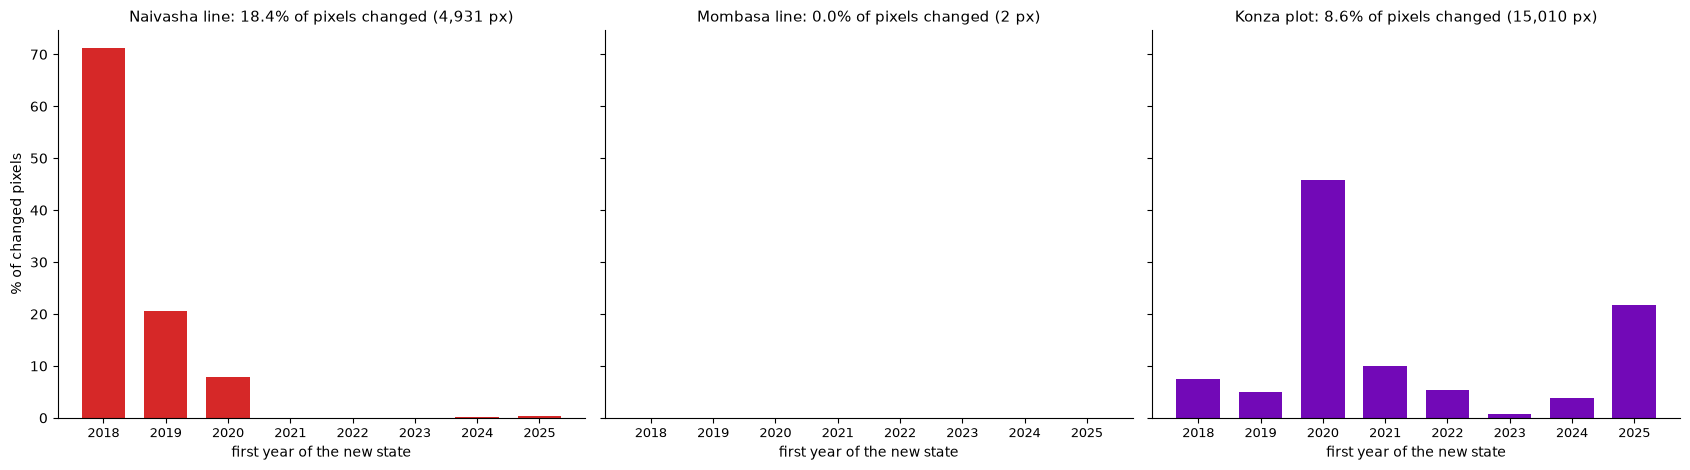

In [6]:
# ---------------------------------------------------------------------------
# THE CHART: when did the changed pixels change?
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
for ax, zone, colour in zip(axes, ("Naivasha line", "Mombasa line", "Konza plot"),
                            ("#d62828", "#1f6f9c", "#7209b7")):
    ax.bar(YEARS[1:], 100 * table.loc[zone, YEARS[1:]].fillna(0), color=colour, width=0.7)
    ax.set_xticks(YEARS[1:]); ax.tick_params(axis="x", labelsize=9)
    ax.set_title(f"{zone}: {table.loc[zone, 'changed']:.1%} of pixels changed "
                 f"({table.loc[zone, 'changed_px']:,} px)", fontsize=11)
    ax.set_xlabel("first year of the new state")
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("% of changed pixels")
plt.tight_layout(); plt.show()

One caution on reading dates. Even in the **background**, changed pixels pile
up at the ends of the record: 32% are dated 2018 and 28% 2025. A change that
happened before 2017 or is still under way gets pushed to the first or last
year. So a date of 2018 or 2025 is the least precise; dates in between are the
reliable ones. The Naivasha line still stands apart: nothing after 2020, where
the background has 44% of its changes in 2024–2025.

## 5. The escarpment, as a map

The tile `(36.55, -1.15)` has 12 km of the Naivasha line. Left and middle: the
tile in 2017 and 2025 (PCA false colour, so colours compare only within one
image). Right: every changed pixel, coloured by the year its new state starts,
with the OSM track drawn over it.

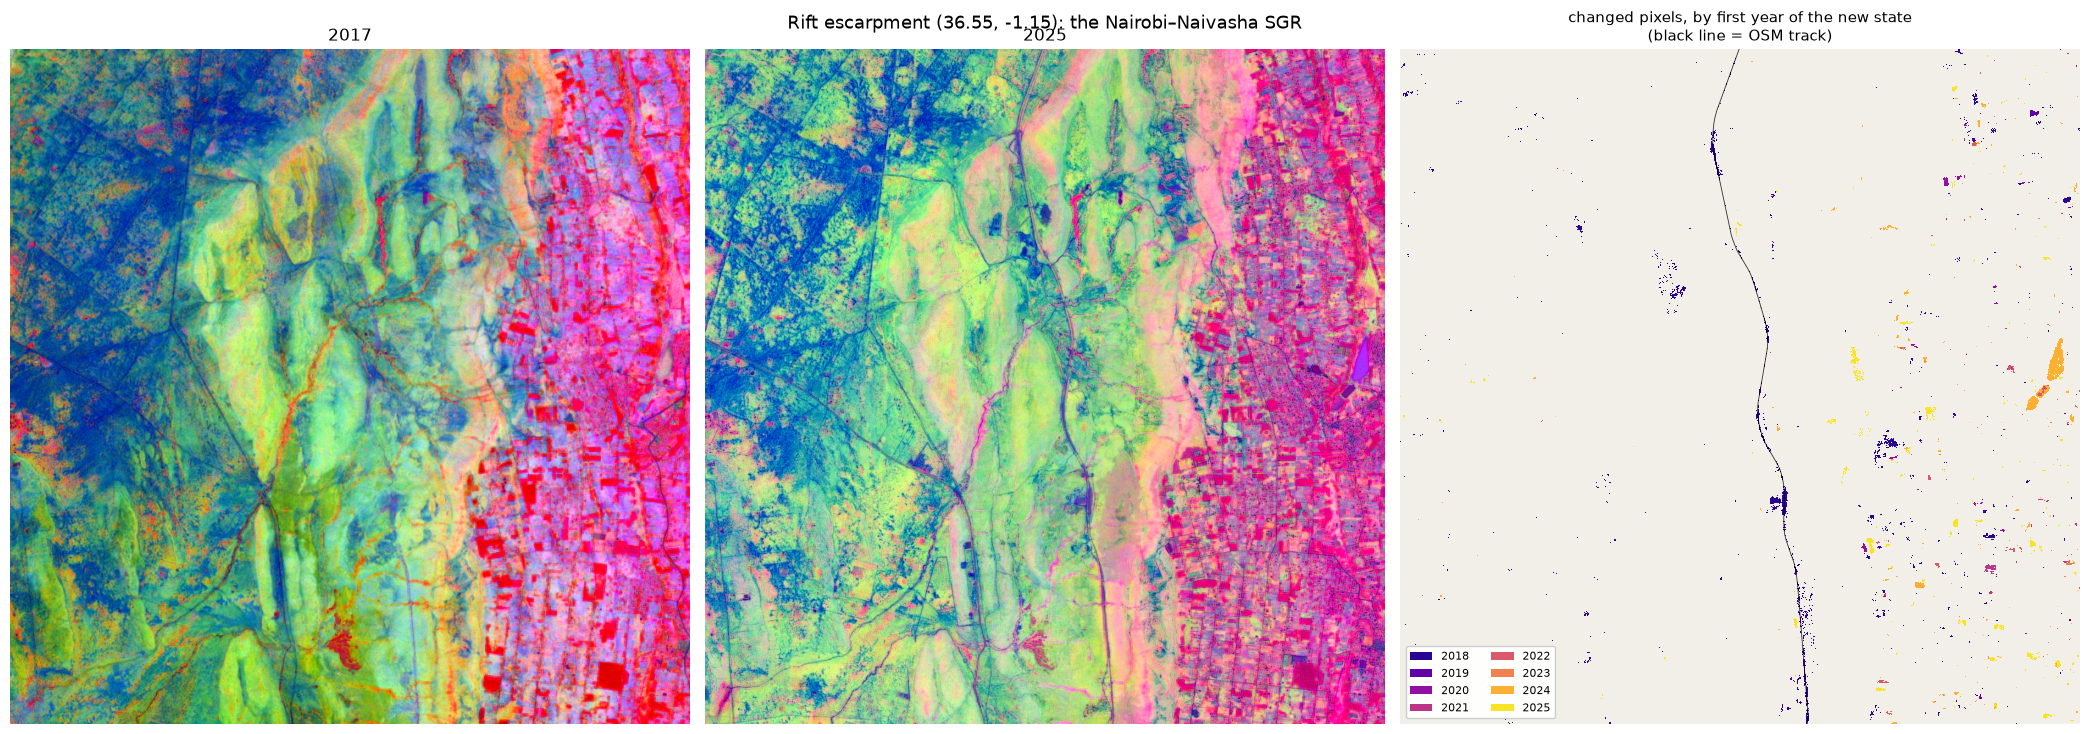

on satellite imagery: https://www.google.com/maps/@-1.15300,36.55300,15z/data=!3m1!1e3


In [7]:
# ---------------------------------------------------------------------------
# ESCARPMENT TILE: 2017, 2025, AND THE CHANGE-YEAR MAP
# ---------------------------------------------------------------------------
def change_year_image(t):
    r = results[t]
    return np.where(np.isfinite(r["distance"]) & (r["distance"] > CUT), r["first_new"], 0)

year_cols = plt.cm.plasma(np.linspace(0.05, 0.95, len(YEARS) - 1))
year_cmap = ListedColormap(["#f2efe8", *year_cols])

def draw_track(ax, t, phases=("Nairobi-Naivasha", "Mombasa-Nairobi")):
    crs, transform, (h, w) = geo[t]
    inv = ~transform
    for phase in phases:
        for g in sgr[sgr.phase == phase].to_crs(crs).geometry:
            cols, rows = zip(*(inv * xy for xy in g.coords))
            ax.plot(cols, rows, color="black", lw=0.6, alpha=0.8)
    ax.set_xlim(0, w); ax.set_ylim(h, 0)      # the track runs past the tile; stay on the tile

def show_tile(t, title):
    fig, axes = plt.subplots(1, 3, figsize=(21, 7.4))
    for ax, year in zip(axes[:2], (YEARS[0], YEARS[-1])):
        tile = list(gt.fetch_embeddings([(year, *t)]))[0]
        ax.imshow(K.false_colour(gt, tile)); ax.set_title(str(year), fontsize=12); ax.axis("off")
    axes[2].imshow(change_year_image(t), cmap=year_cmap, vmin=-0.5, vmax=len(YEARS) - 0.5,
                   interpolation="nearest")
    draw_track(axes[2], t)
    axes[2].set_title("changed pixels, by first year of the new state\n(black line = OSM track)", fontsize=11)
    axes[2].axis("off")
    axes[2].legend(handles=[Patch(fc=c, label=str(y)) for y, c in zip(YEARS[1:], year_cols)],
                   loc="lower left", fontsize=8, ncol=2, framealpha=0.95)
    fig.suptitle(title, fontsize=13)
    plt.tight_layout(); plt.show()

show_tile((36.55, -1.15), "Rift escarpment (36.55, -1.15): the Nairobi–Naivasha SGR")
print("on satellite imagery:", K.gmaps(36.553, -1.153))

The railway is **absent in 2017 and a clear new line in 2025** in the false
colour. In the change map, the changed pixels follow the OSM track, almost all
dated 2018. Most of the other patches, many dated 2024–2025, are in the
farmland on the east of the tile and are unrelated to the railway.

## 6. Konza

The city plot spans two tiles, so the change-year map is drawn for both, with
the OSM outline in purple and the Mombasa–Nairobi line in black.

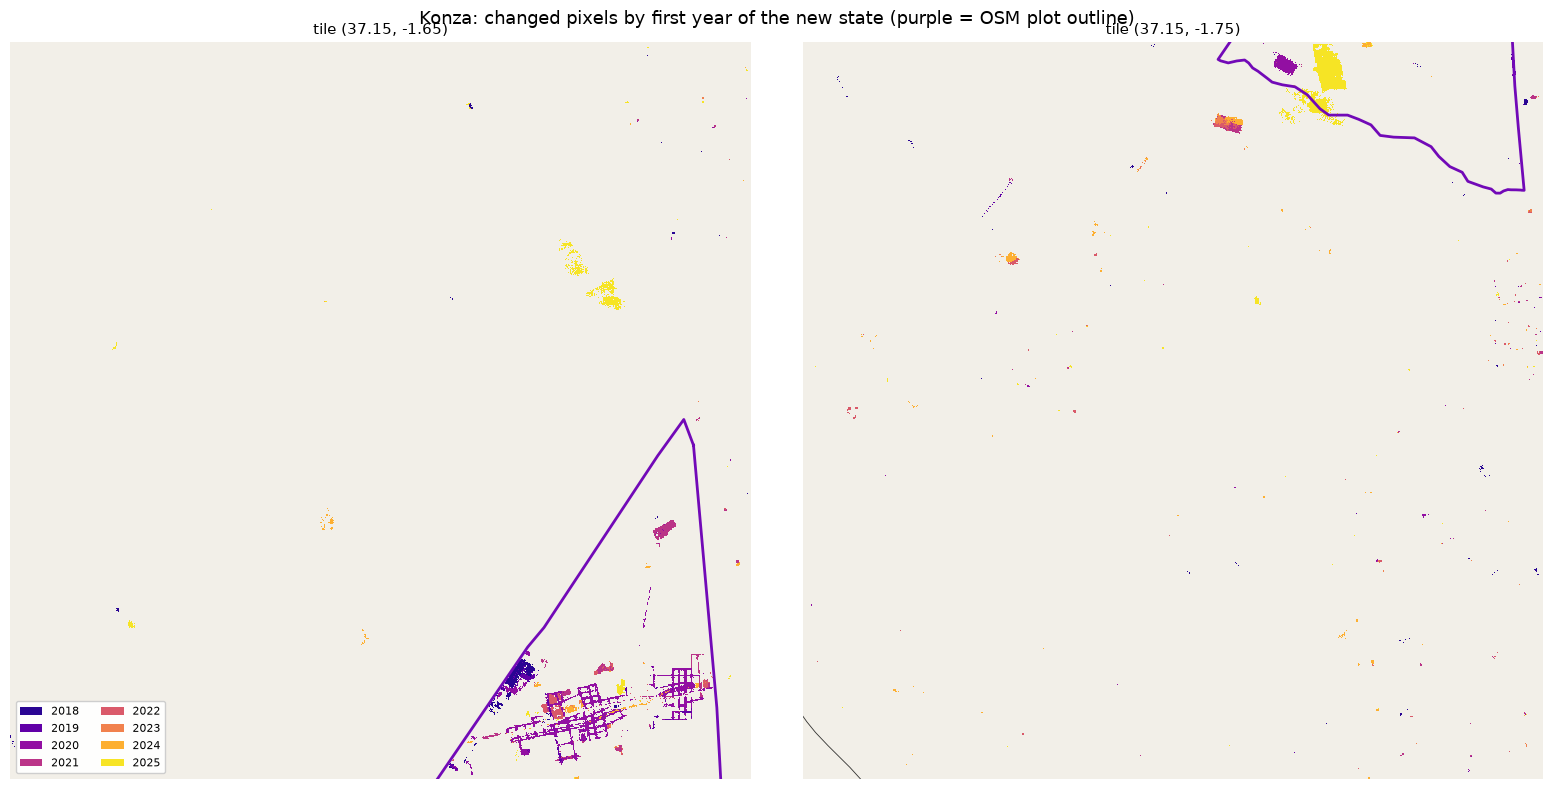

area inside the Konza plot that changed, by first year of the new state (km^2):
2018     0.11
2019     0.07
2020     0.69
2021     0.15
2022     0.08
2023     0.01
2024     0.06
2025     0.33
total: 1.50 km^2 of 17.4 km^2

on satellite imagery: https://www.google.com/maps/@-1.68800,37.18500,15z/data=!3m1!1e3


In [8]:
# ---------------------------------------------------------------------------
# KONZA: CHANGE-YEAR MAP, AND AREA CHANGED PER YEAR INSIDE THE PLOT
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, t in zip(axes, [(37.15, -1.65), (37.15, -1.75)]):
    ax.imshow(change_year_image(t), cmap=year_cmap, vmin=-0.5, vmax=len(YEARS) - 0.5,
              interpolation="nearest")
    crs, transform, _ = geo[t]
    inv = ~transform
    for g in konza.to_crs(crs).geometry:
        cols, rows = zip(*(inv * xy for xy in g.exterior.coords))
        ax.plot(cols, rows, color="#7209b7", lw=2)
    draw_track(ax, t, phases=("Mombasa-Nairobi",))     # also clips the view to the tile
    ax.set_title(f"tile {t}", fontsize=11); ax.axis("off")
axes[0].legend(handles=[Patch(fc=c, label=str(y)) for y, c in zip(YEARS[1:], year_cols)],
               loc="lower left", fontsize=8, ncol=2, framealpha=0.95)
fig.suptitle("Konza: changed pixels by first year of the new state (purple = OSM plot outline)", fontsize=13)
plt.tight_layout(); plt.show()

per_year = pd.Series(0.0, index=YEARS[1:])
for t in [(37.15, -1.65), (37.15, -1.75)]:
    r, inside = results[t], zones[t]["Konza plot"]
    changed = inside & np.isfinite(r["distance"]) & (r["distance"] > CUT)
    for i, y in enumerate(YEARS[1:], start=1):
        per_year[y] += (changed & (r["first_new"] == i)).sum() / 1e4
print("area inside the Konza plot that changed, by first year of the new state (km^2):")
print(per_year.to_string(float_format=lambda v: f"{v:6.2f}"))
print(f"total: {per_year.sum():.2f} km^2 of {konza.to_crs('EPSG:32637').area.sum() / 1e6:.1f} km^2")
print("\non satellite imagery:", K.gmaps(37.185, -1.688))

Inside the Konza plot, the changed pixels form a **street grid**, dated mostly
**2020**: the Phase 1 road network, drawn from the embeddings alone. In total
**1.5 km²** of the 17.4 km² plot changed, close to the **170 ha (1.7 km²)**
published for Phase 1, which is only a small part of the full plot. 22% of the
changed area is dated 2025, the end year, where dates are least reliable (see
above).


## 7. What this notebook establishes

1. **Built change is detectable, and datable, with no labels.** Along the
   Nairobi–Naivasha SGR, 18.4% of the corridor changed, 18 times the background
   rate, and 92% of those changes are dated 2018–2019, the published
   construction window.

2. **It detects new construction, not old.** The Mombasa–Nairobi line, open
   since May 2017, shows 2 changed pixels out of about 9,000. This control is
   what makes the dates believable.

3. **A new city appears as a street grid.** Konza's Phase 1 roads show up as a
   grid inside the plot, mostly dated 2020, covering 1.5 km² against the
   published 1.7 km² for Phase 1.

**Limits, stated plainly:**

- **Dates at the ends are the least precise.** A change before 2017 or still
  under way gets dated 2018 or 2025; even the background shows this.
- **One change per pixel.** `K.step_change` finds the single biggest shift. A
  pixel cleared in 2018 and built on in 2021 gets one date.
- **"Changed" is relative.** The cut-off is the 99th percentile of background
  change in these tiles. The background itself contains real change (farms,
  new roads, houses), so the cut-off is conservative, and it would need
  re-setting in a different landscape.
- **The corridor catches only 18%** of its pixels, for reasons (tunnels,
  viaducts, map offsets) this notebook does not separate.
